# 直近の得点状況・リード状況別「次の得点」までの待ち時間（打ち切りを考慮）

`recent_score.ipynb` と同じ、`statsbomb_data` 以下の全リーグ・全シーズンの
`*_goals_and_red_cards.csv` を用いる。`survival_score_difference.ipynb` と同じ
「区間ベース」の考え方で、得点が入るたびに、それまで進行中だった home・away 双方の観測
（時計）を**その時点で必ず打ち切り**、その得点直後の新しい状態に基づいて home・away
それぞれに**新しい観測を今この瞬間から開始する**。

例えば 2-0 → 2-1（awayが得点）になった場合:

- それまでの home の観測（例えば「リード中・直近得点チーム」として計測中だったもの）は、
  **この時点で「相手の得点による打ち切り」（赤）**として終了する。
- それまでの away の観測は**イベント成立**（awayが得点した）として終了する。
- 2-1になった瞬間から、home は「リード中・直近失点チーム」、away は
  「ビハインド中・直近得点チーム」として、**新しい観測がここから始まる**。

キックオフ（0-0）も他の区分と全く同じ扱いで、試合開始と同時に home・away それぞれの
「0-0」観測が始まる。最初の得点が入ればイベント成立とその裏側の「相手の得点による打ち切り」
（赤）のペアが、0-0のまま試合終了すれば home・away とも「試合終了による打ち切り」（青）が
記録される（無得点で終わった試合も、home・away 2件の「0-0・試合終了による打ち切り」観測に
なる）。

これにより、打ち切りは次の2種類になる。

- **打ち切り（相手の得点による, 赤）**: 観測中のチームより先に相手チームが得点した場合。
- **打ち切り（試合終了による, 青）**: 観測中のチームがその状態のまま試合終了を迎えた場合。

## 区分（7区分）

| 区分 | 内容 |
|---|---|
| 0-0 | キックオフ〜最初の得点（home/away対称、どちらの視点でも同じ「0-0」） |
| リード中・直近得点チーム | 現在リード中で、直近の得点も自分（リードを決めた/広げた） |
| リード中・直近失点チーム | 現在リード中だが、直近の得点は相手（リードを許した） |
| ビハインド中・直近得点チーム | 現在ビハインド中だが、直近の得点は自分（差を縮めた） |
| ビハインド中・直近失点チーム | 現在ビハインド中で、直近の得点も相手（差を広げられた） |
| 同点(0-0以外)・直近得点チーム | 自分の得点で同点に追いついた直後 |
| 同点(0-0以外)・直近失点チーム | 相手の得点で同点に追いつかれた直後 |

- 入力：`statsbomb_data/**/*_goals_and_red_cards.csv`（全リーグ・全シーズン）
- 出力：7区分の待ち時間ヒストグラム、Kaplan-Meier曲線（打ち切りを示す縦線・S(t)=0.5の
  水平線・生存時間中央値付き）、全区分まとめてのKaplan-Meier曲線、全組み合わせの
  ログランク検定


## データ形式・生存時間データの作り方

`survival_score_difference.ipynb` と同じ `goals_and_red_cards.csv`（得点イベントの行のみ、
`minute + second/60` を実時間・分として使用）と、各試合に1行だけ存在する試合終了行
（`home_away`・`red_card` がともに欠損で `end_time_minutes` が非欠損の行、
`end_time_minutes + end_time_second/60` が試合終了時刻）を用いる。

試合ごとに、キックオフ（t=0、状態は home・away とも「0-0」）→ 最初の得点 → ... →
最後の得点 → 試合終了、という時系列上の区間を作る。各区間の開始時点（直前の得点の直後、
最初の区間はキックオフ）の状態から、home・away それぞれについて上の7区分のいずれかを
1つ割り当てる。

| 状態 | 直近の得点者がその側自身 | 直近の得点者が相手側 |
|---|---|---|
| リード中 | リード中・直近得点チーム | リード中・直近失点チーム |
| ビハインド中 | ビハインド中・直近得点チーム | ビハインド中・直近失点チーム |
| 同点(0-0以外) | 同点(0-0以外)・直近得点チーム（同点にした側） | 同点(0-0以外)・直近失点チーム（同点にされた側） |

この区間が次の得点で終わる場合、得点したチーム側の観測は**イベント**、もう一方の観測は
**相手の得点による打ち切り**。区間が試合終了で終わる場合（各試合の最後の区間）は、
home・awayとも**試合終了による打ち切り**。

`survival_score_difference.ipynb` の `build_survival_events` と全く同じ「区間を作って
home・away2件ずつ記録する」ループ構造を使い、区分ラベルの決め方だけが異なる。


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフ内の日本語（タイトル・軸ラベル等）が文字化けしないよう、macOS標準の日本語フォントを指定する。
# （Windows等、別環境で開く場合は "Meiryo" や "Yu Gothic" などお使いの環境にある日本語フォント名に変更してください）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 打ち切りの種類ごとの色（Kaplan-Meier曲線上の縦線・凡例で共通して使う）
CENSOR_OPPONENT_COLOR = "red"   # 相手の得点による打ち切り
CENSOR_MATCHEND_COLOR = "blue"  # 試合終了による打ち切り
MEDIAN_COLOR = "#009E73"        # 生存時間中央値の線の色


/Users/fujitaharukanin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. 全リーグ・全シーズンのデータを読み込む

In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 試合ごとに区間を作り、打ち切りを含む生存時間データを作る

各試合について、得点イベントを時刻順に並べ、得点が入るたびに進行中の home・away の観測を
打ち切って（もう一方は得点によるイベント）、新しい観測をその瞬間から開始する。キックオフ
（t=0）も他の区分と対称に扱い、home・away とも「0-0」の観測から始める。


In [3]:
def _labels_after_goal(home_score, away_score, scorer_side):
    """
    ある得点によって home_score, away_score になった直後の状態から、home(0)・away(1) それぞれに
    割り当てる新しい区分ラベルを返す（{side: category} の辞書）。scorer_side はこの得点を
    決めた側（0=home, 1=away）。
    """
    diff = home_score - away_score
    if diff == 0:
        # 同点(0-0以外)に戻った直後: 得点した側(scorer_side)が「同点にした側」、
        # もう一方が「それまでリードしていて同点にされた側」。
        trailer_before = scorer_side
        leader_before = 1 - scorer_side
        return {leader_before: "同点(0-0以外)・直近失点チーム", trailer_before: "同点(0-0以外)・直近得点チーム"}

    leader = 0 if diff > 0 else 1
    trailer = 1 - leader
    if scorer_side == leader:
        return {leader: "リード中・直近得点チーム", trailer: "ビハインド中・直近失点チーム"}
    else:
        return {leader: "リード中・直近失点チーム", trailer: "ビハインド中・直近得点チーム"}


CATEGORY_ORDER = [
    "0-0",
    "リード中・直近得点チーム", "リード中・直近失点チーム",
    "ビハインド中・直近得点チーム", "ビハインド中・直近失点チーム",
    "同点(0-0以外)・直近得点チーム", "同点(0-0以外)・直近失点チーム",
]


def build_survival_recent_score_events(df):
    """
    goals_and_red_cards の df（複数リーグ・シーズンを結合したものでも可）から、試合ごとに
    「キックオフ→最初の得点」「得点→次の得点」「最後の得点→試合終了」の区間を作る。

    キックオフの瞬間（t=0）から、home・away ともに「0-0」の観測が始まる。以降、得点が
    入るたびに進行中の home・away 双方の観測をこの時点で打ち切り（得点した側はイベント、
    もう一方は相手の得点による打ち切り）、この得点直後の状態から home・away それぞれに
    新しい区分ラベル（_labels_after_goal）を割り当てて、新しい観測をこの瞬間から始める。
    試合終了時点で残っている観測は、home・awayとも試合終了による打ち切りとして記録する。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)
    group_cols = ["league_code", "season_name", "match_id"]
    goal_groups = {key: g.sort_values("time_min") for key, g in goal_rows.groupby(group_cols)}

    # 試合終了行: home_away・red_card がともに欠損で、end_time_minutes が非欠損の行（試合につき1行）。
    end_rows = df[df["red_card"].isna() & df["home_away"].isna() & df["end_time_minutes"].notna()].copy()
    end_rows["full_time_min"] = end_rows["end_time_minutes"].astype(float) + end_rows["end_time_second"].astype(float) / 60.0

    records = []
    for row in end_rows.itertuples(index=False):
        key = (row.league_code, row.season_name, row.match_id)
        full_time = row.full_time_min
        meta = dict(league_code=row.league_code, season_name=row.season_name, match_id=row.match_id)

        g = goal_groups.get(key)
        if g is None:
            times = np.array([])
            sides = np.array([], dtype=int)
        else:
            times = g["time_min"].to_numpy()
            sides = g["home_away"].to_numpy()  # 0=home, 1=away
        k = len(times)

        home_score = away_score = 0
        # キックオフ(t=0)から、home・awayとも「0-0」の観測を対称に開始する。
        pending = {0: {"category": "0-0", "start_time": 0.0}, 1: {"category": "0-0", "start_time": 0.0}}

        for i in range(k):
            t_i = float(times[i])
            s_i = int(sides[i])

            # 直前の区間（pending）をこの得点で打ち切る/イベント成立させる。
            for side, info in pending.items():
                if side == s_i:
                    records.append({**meta, "category": info["category"], "team": "home" if side == 0 else "away",
                                     "waiting_time": t_i - info["start_time"], "event": 1, "censor_type": None})
                else:
                    records.append({**meta, "category": info["category"], "team": "home" if side == 0 else "away",
                                     "waiting_time": t_i - info["start_time"], "event": 0, "censor_type": "opponent"})

            if s_i == 0:
                home_score += 1
            else:
                away_score += 1

            # この得点直後の状態から、home・away の新しい区分ラベルを決め、この瞬間から観測を開始する。
            new_labels = _labels_after_goal(home_score, away_score, s_i)
            pending = {side: {"category": cat, "start_time": t_i} for side, cat in new_labels.items()}

        # 試合終了: 最後の区間を試合終了による打ち切りとして記録する（0-0で終わった試合も含む）。
        for side, info in pending.items():
            records.append({**meta, "category": info["category"], "team": "home" if side == 0 else "away",
                             "waiting_time": full_time - info["start_time"], "event": 0, "censor_type": "match_end"})

    return pd.DataFrame(records)


survival_df = build_survival_recent_score_events(df_all)
n_event = int((survival_df["event"] == 1).sum())
n_cens_opp = int((survival_df["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER)


観測数: 18850（イベント: 6964, 相手の得点による打ち切り: 6964, 試合終了による打ち切り: 4922）


event,0,1
category,,
0-0,2618,2304
リード中・直近得点チーム,3091,2290
リード中・直近失点チーム,371,146
ビハインド中・直近得点チーム,403,114
ビハインド中・直近失点チーム,3912,1469
同点(0-0以外)・直近得点チーム,748,318
同点(0-0以外)・直近失点チーム,743,323


## 3. ヒストグラムの区分（ビン）を共通化する

`survival_score_difference.ipynb` と同様、待ち時間（分）のビン幅は5分刻みとし、イベント・
打ち切りを問わず全ての観測の最大待ち時間からビンの上限を決めて、全グラフで共通のビン境界を
使う。


In [4]:
BIN_WIDTH = 5  # 分
max_wait = survival_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 99.83分 -> ビン境界: 0〜100分（5分刻み、20ビン）


## 4. 区分ごとにKaplan-Meier曲線をあてはめる

`survival_score_difference.ipynb` と同じく、7区分それぞれについて `KaplanMeierFitter` を
あてはめておき、ヒストグラムの中央値線・KM曲線の両方で使い回す。生存時間中央値は
`me = min{t : Ŝ(t) ≤ 0.5}`（`lifelines` の `median_survival_time_`）。


In [5]:
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
except ModuleNotFoundError:
    # このノートブックのカーネルに lifelines が入っていない場合、自動でインストールする。
    # 同一プロセス内で numpy/matplotlib 等の依存が更新されると壊れることがあるため、
    # インストール後はあえて処理を止め、カーネル再起動を促す。
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )

km_fits = {}
km_summary_rows = []

for cat in CATEGORY_ORDER:
    sub = survival_df[survival_df["category"] == cat]
    n = len(sub)
    if n == 0:
        km_fits[cat] = None
        km_summary_rows.append({"区分": cat, "n": 0, "イベント数": 0,
                                 "相手の得点による打ち切り": 0, "試合終了による打ち切り": 0,
                                 "生存時間中央値me(分)": np.nan})
        continue

    n_event = int((sub["event"] == 1).sum())
    n_cens_opp = int((sub["censor_type"] == "opponent").sum())
    n_cens_end = int((sub["censor_type"] == "match_end").sum())

    kmf = KaplanMeierFitter()
    kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"{cat} (n={n})")
    km_fits[cat] = kmf

    km_summary_rows.append({"区分": cat, "n": n, "イベント数": n_event,
                             "相手の得点による打ち切り": n_cens_opp, "試合終了による打ち切り": n_cens_end,
                             "生存時間中央値me(分)": kmf.median_survival_time_})

km_summary = pd.DataFrame(km_summary_rows).set_index("区分").reindex(CATEGORY_ORDER)
km_summary


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
0-0,4922,2304,2304,314,50.683333
リード中・直近得点チーム,5381,2290,1469,1622,35.466667
リード中・直近失点チーム,517,146,114,257,37.516667
ビハインド中・直近得点チーム,517,114,146,257,50.050000
ビハインド中・直近失点チーム,5381,1469,2290,1622,51.900000
同点(0-0以外)・直近得点チーム,1066,318,323,425,51.683333
同点(0-0以外)・直近失点チーム,1066,323,318,425,47.283333


## 5. 7区分の待ち時間ヒストグラムを描画する

各パネルで、イベント・打ち切りを区別せず全ての観測（`waiting_time`）をヒストグラムにし、
生存時間中央値 `me` の位置に点線を1本重ねて表示する（平均・最頻値・分散などは打ち切りのある
分布では単純に計算できないため、ここでは表示しない）。


保存しました: ./figures/survival_recent_score_histograms.png


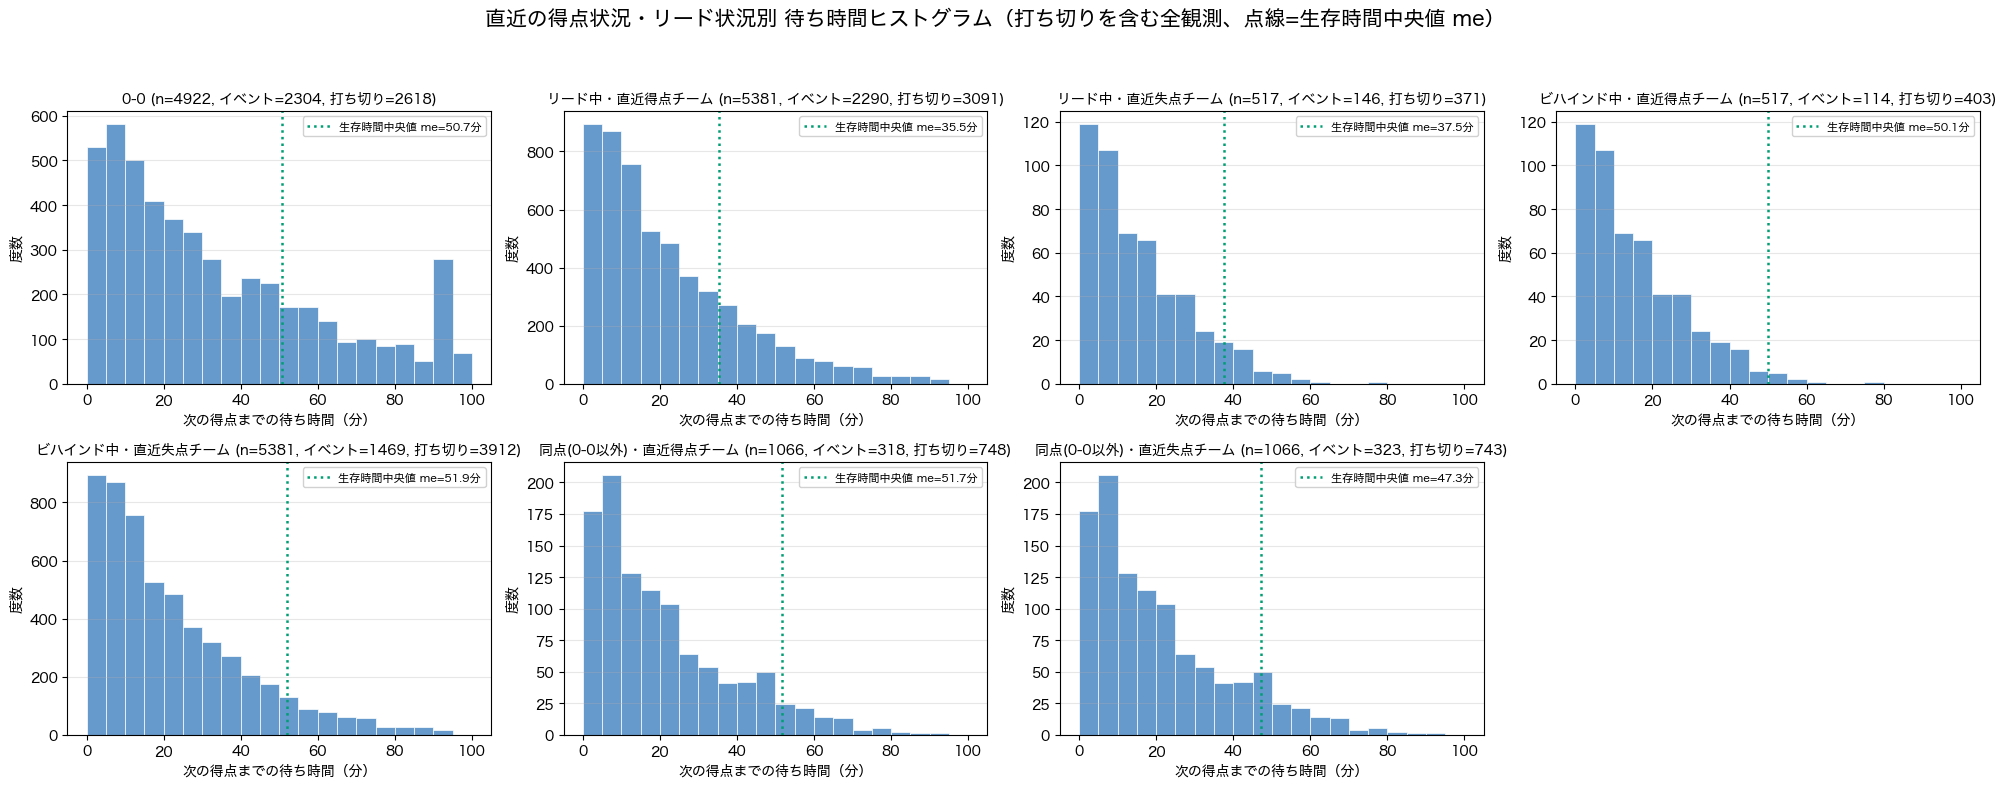

In [6]:
BAR_COLOR = "#6699CC"


def plot_hist_with_km_median(ax, sub_df, kmf, title, bin_edges):
    vals = sub_df["waiting_time"].values
    n = len(vals)
    n_event = int((sub_df["event"] == 1).sum())
    n_cens = n - n_event

    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(bin_edges[:-1], counts, width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)

    if kmf is not None:
        me = kmf.median_survival_time_
        if np.isfinite(me):
            ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.8,
                        label=f"生存時間中央値 me={me:.1f}分")
            ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    ax.set_title(f"{title} (n={n}, イベント={n_event}, 打ち切り={n_cens})", fontsize=10)
    ax.set_xlabel("次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    sub = survival_df[survival_df["category"] == cat]
    plot_hist_with_km_median(axes[i], sub, km_fits[cat], cat, BIN_EDGES)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("直近の得点状況・リード状況別 待ち時間ヒストグラム（打ち切りを含む全観測、点線=生存時間中央値 me）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_recent_score_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 6. 区分ごとのKaplan-Meier曲線（打ち切り時刻・中央値を表示）

区分ごとに1パネルずつKaplan-Meier曲線を描く。

- 打ち切りが起きた時刻には、その時刻における曲線の生存確率の高さに短い縦線
  （ティックマーク）を重ね、**赤**=相手の得点による打ち切り、**青**=試合終了による打ち切り
  で色分けする。
- 生存確率 S(t)=0.5 の位置に灰色の破線（水平線）を引き、生存時間中央値
  `me = min{t : Ŝ(t) ≤ 0.5}` の位置に緑の点線（垂直線）と、その値を示す注記を入れる。


保存しました: ./figures/survival_recent_score_km_curves_grid.png


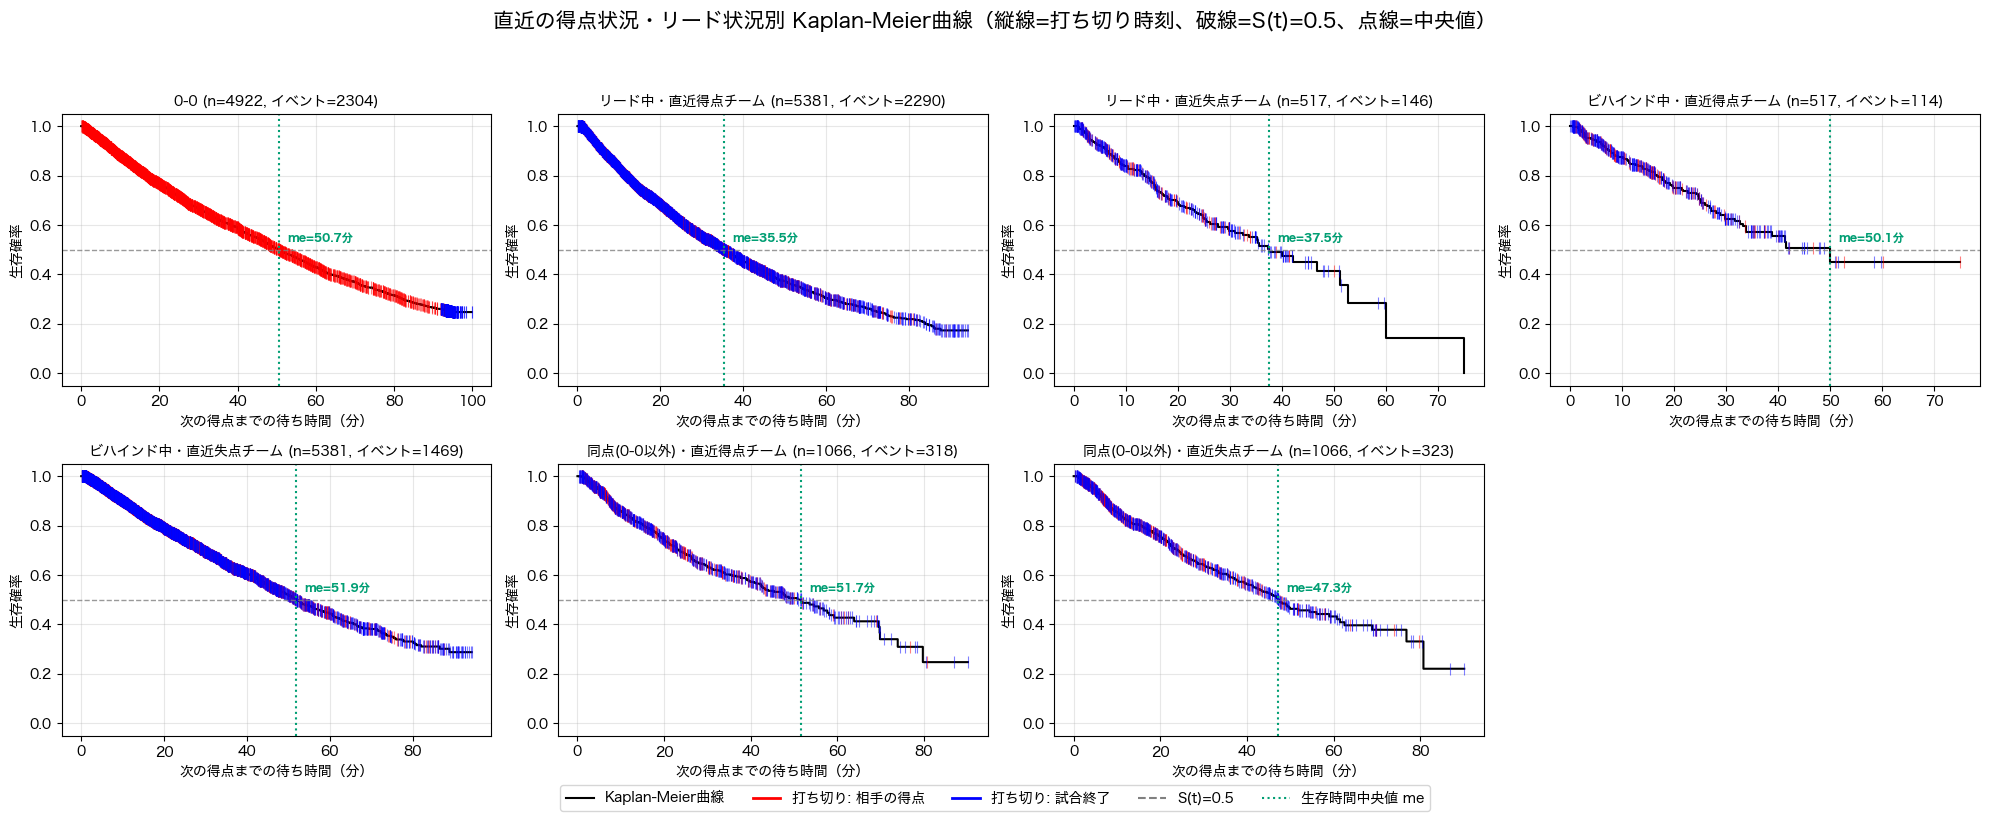

In [7]:
def plot_km_with_censor_marks(ax, sub_df, kmf, title, tick_height=0.025):
    n = len(sub_df)
    n_event = int((sub_df["event"] == 1).sum())

    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False, legend=False,
                                color="black", linewidth=1.5)

    for censor_type, color in [("opponent", CENSOR_OPPONENT_COLOR), ("match_end", CENSOR_MATCHEND_COLOR)]:
        t_cens = sub_df.loc[sub_df["censor_type"] == censor_type, "waiting_time"].values
        if len(t_cens) == 0:
            continue
        s_vals = kmf.survival_function_at_times(t_cens).values
        ax.vlines(t_cens, s_vals - tick_height, s_vals + tick_height,
                   color=color, linewidth=0.8, alpha=0.5)

    # S(t)=0.5 の水平線
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    # 生存時間中央値 me の垂直線・注記
    me = kmf.median_survival_time_
    if np.isfinite(me):
        ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.5)
        ax.annotate(f"me={me:.1f}分", xy=(me, 0.5), xytext=(6, 6),
                    textcoords="offset points", fontsize=8, color=MEDIAN_COLOR,
                    fontweight="bold")

    ax.set_title(f"{title} (n={n}, イベント={n_event})", fontsize=10)
    ax.set_xlabel("次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    kmf = km_fits[cat]
    if kmf is None:
        axes[i].axis("off")
        continue
    sub = survival_df[survival_df["category"] == cat]
    plot_km_with_censor_marks(axes[i], sub, kmf, cat)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("直近の得点状況・リード状況別 Kaplan-Meier曲線（縦線=打ち切り時刻、破線=S(t)=0.5、点線=中央値）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_recent_score_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


## 7. 7区分をまとめて比較するKaplan-Meier曲線

7区分を1枚に重ねて比較する。区分数が少ないため、色覚に配慮した Okabe-Ito の配色
（7色とも十分に見分けやすい）を区分ごとに固定で割り当てる。


保存しました: ./figures/survival_recent_score_km_curves_overlay.png


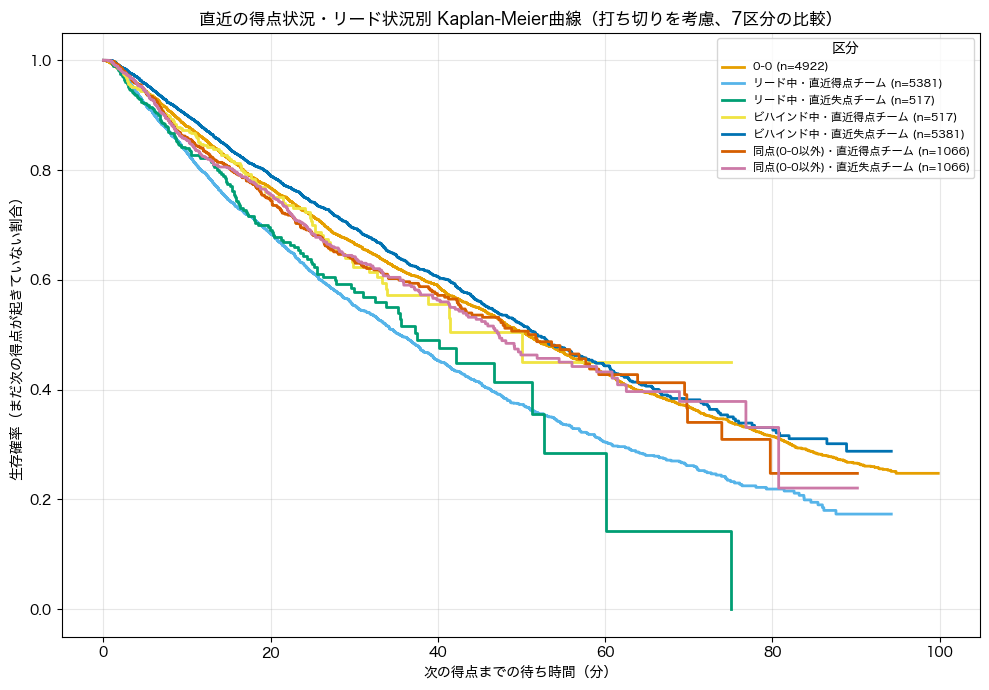

In [8]:
# Okabe-Ito配色（色覚異常の方にも見分けやすいことが確認されている定番のパレット）
CATEGORY_COLORS = {
    "0-0": "#E69F00",
    "リード中・直近得点チーム": "#56B4E9",
    "リード中・直近失点チーム": "#009E73",
    "ビハインド中・直近得点チーム": "#F0E442",
    "ビハインド中・直近失点チーム": "#0072B2",
    "同点(0-0以外)・直近得点チーム": "#D55E00",
    "同点(0-0以外)・直近失点チーム": "#CC79A7",
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat in CATEGORY_ORDER:
    kmf = km_fits[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS[cat], linewidth=2)

ax.set_xlabel("次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ次の得点が起きていない割合）")
ax.set_title("直近の得点状況・リード状況別 Kaplan-Meier曲線（打ち切りを考慮、7区分の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper right", title="区分")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_recent_score_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 8. ログランク検定（打ち切りを考慮）

7区分を一括で比較する `multivariate_logrank_test` と、区分ペアごとの
`pairwise_logrank_test`（7C2 = 21通り）の両方を、`event_observed` に打ち切り情報を渡した
上で行う。ペアワイズ比較は多重比較になるため、参考として Bonferroni 補正後のp値も併記する。


In [9]:
# 7区分を一括で比較するログランク検定（打ち切りを考慮）
overall_result = multivariate_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)
print("=== 7区分一括のログランク検定（打ち切りを考慮） ===")
overall_result.print_summary()

# 区分間のペアワイズ比較（7C2 = 21通り、打ち切りを考慮）
pairwise_result = pairwise_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)

pairwise_summary = pairwise_result.summary.copy()
n_comparisons = len(pairwise_summary)
pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
pairwise_summary = pairwise_summary.sort_values("p")

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# p値そのものに有意水準の星を付けた文字列に置き換える（例: 2.352009e-26***）
pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

print(f"\n=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
pairwise_summary


=== 7区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=21） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


test_statistic                p  \
ビハインド中・直近失点チーム    リード中・直近得点チーム           179.332962  6.777403e-41***   
0-0               リード中・直近得点チーム           134.135894  5.102098e-31***   
ビハインド中・直近失点チーム    リード中・直近失点チーム            25.165955  5.260264e-07***   
リード中・直近得点チーム      同点(0-0以外)・直近得点チーム       24.954488  5.869971e-07***   
                  同点(0-0以外)・直近失点チーム       22.763420  1.832202e-06***   
0-0               リード中・直近失点チーム            13.831022  2.000066e-04***   
ビハインド中・直近得点チーム    リード中・直近得点チーム             9.598271  1.947607e-03***   
ビハインド中・直近失点チーム    同点(0-0以外)・直近失点チーム        7.284624  6.954728e-03***   
                  同点(0-0以外)・直近得点チーム        5.945319   1.475642e-02**   
リード中・直近失点チーム      同点(0-0以外)・直近得点チーム        5.750654   1.648252e-02**   
0-0               ビハインド中・直近失点チーム           5.324218   2.103104e-02**   
リード中・直近失点チーム      同点(0-0以外)・直近失点チーム        5.287721   2.147631e-02**   
ビハインド中・直近得点チーム    リード中・直近失点チーム             3.939072   4.717678e-02**   
ビハインド中・直近失点チーム    ビハインド中・直近得点チーム           3.654213    5.592756e-02*   
0-0               同点(0-0以外)・直近失点チーム        1.591335     2.071354e-01   
                  同点(0-0以外)・直近得点チーム        0.986857     3.205118e-01   
                  ビハインド中・直近得点チーム           0.559783     4.543478e-01   
リード中・直近失点チーム      リード中・直近得点チーム             0.326254     5.678731e-01   
同点(0-0以外)・直近失点チーム 同点(0-0以外)・直近得点チーム        0.039005     8.434385e-01   
ビハインド中・直近得点チーム    同点(0-0以外)・直近失点チーム        0.038602     8.442400e-01   
                  同点(0-0以外)・直近得点チーム        0.010745     9.174410e-01   

                                       -log2(p)     p_bonferroni  
ビハインド中・直近失点チーム    リード中・直近得点チーム       133.438319  1.423255e-39***  
0-0               リード中・直近得点チーム       100.628680  1.071441e-29***  
ビハインド中・直近失点チーム    リード中・直近失点チーム        20.858362  1.104655e-05***  
リード中・直近得点チーム      同点(0-0以外)・直近得点チーム   20.700143  1.232694e-05***  
                  同点(0-0以外)・直近失点チーム   19.057990  3.847623e-05***  
0-0               リード中・直近失点チーム        12.287665  4.200138e-03***  
ビハインド中・直近得点チーム    リード中・直近得点チーム         9.004082   4.089974e-02**  
ビハインド中・直近失点チーム    同点(0-0以外)・直近失点チーム    7.167790     1.460493e-01  
                  同点(0-0以外)・直近得点チーム    6.082513     3.098848e-01  
リード中・直近失点チーム      同点(0-0以外)・直近得点チーム    5.922920     3.461329e-01  
0-0               ビハインド中・直近失点チーム       5.571336     4.416518e-01  
リード中・直近失点チーム      同点(0-0以外)・直近失点チーム    5.541110     4.510026e-01  
ビハインド中・直近得点チーム    リード中・直近失点チーム         4.405779     9.907124e-01  
ビハインド中・直近失点チーム    ビハインド中・直近得点チーム       4.160297     1.000000e+00  
0-0               同点(0-0以外)・直近失点チーム    2.271354     1.000000e+00  
                  同点(0-0以外)・直近得点チーム    1.641551     1.000000e+00  
                  ビハインド中・直近得点チーム       1.138131     1.000000e+00  
リード中・直近失点チーム      リード中・直近得点チーム         0.816360     1.000000e+00  
同点(0-0以外)・直近失点チーム 同点(0-0以外)・直近得点チーム    0.245645     1.000000e+00  
ビハインド中・直近得点チーム    同点(0-0以外)・直近失点チーム    0.244275     1.000000e+00  
                  同点(0-0以外)・直近得点チーム    0.124313     1.000000e+00

## 注意点

- 本ノートブックは `survival_score_difference.ipynb` と同じ「区間ベース」の設計を採用して
  いる。得点が入るたびに進行中の home・away 双方の観測を打ち切り、新しい観測をその瞬間から
  開始するため、`recent_score.ipynb`（打ち切りなし版）とは同じ区分名でも待ち時間の値が
  異なる点に注意（打ち切りなし版は相手の得点を無視して「そのチーム自身の実際の次の得点」まで
  を測っていたが、本ノートブックでは相手が先に得点した時点で打ち切り、そこで観測が終わる）。
- **キックオフ（0-0）も他の6区分と全く対称に扱う**: 試合開始と同時に home・away それぞれの
  「0-0」観測が始まり、最初の得点で一方はイベント・もう一方は相手の得点による打ち切り(赤)、
  0-0のまま試合終了すれば home・away とも試合終了による打ち切り(青)として記録される
  （無得点で終わった試合も home・away 2件の観測になる）。
- 同一試合内の複数の区間・複数の区分にまたがって観測が作られるため、ログランク検定のp値は
  やや過信気味（実際より有意になりやすい）である可能性がある点に注意する
  （`score_difference.ipynb` や `survival_score_difference.ipynb` の集計も同様の性質を持つ）。
- **試合終了時刻の取得**: 各試合に1行だけ存在する「`home_away`・`red_card` がともに
  欠損で `end_time_minutes` が非欠損の行」を試合終了行として使っている。この行が
  存在しない試合は試合終了時刻が分からないため、生存時間データセットから除外している。
- **打ち切りを示す縦線（ティックマーク）**は、打ち切りが起きた時刻におけるKaplan-Meier
  曲線の生存確率の位置に短い縦線として重ねて描画している。観測数が多い区分では線が
  密集して見える点に注意（`tick_height` を小さくする、透明度を下げる、間引くなどで
  調整できる）。
